# Mixture of Experts (MoE) - MobileNetV3

Entrainement multi-tache : **Age, Genre, Ethnicite**

**Architecture :**

```
Input (128x128x3)
    |
MobileNetV3Small (backbone partage, pretrained ImageNet)
    |
GlobalAveragePooling -> BatchNorm -> Dropout
    |
+------------------+------------------+------------------+
|   Gender MoE     |    Age MoE       |  Ethnicity MoE   |
|   3 experts      |    3 experts     |    3 experts     |
|   gating net     |    gating net    |    gating net    |
|   -> sigmoid     |    -> linear     |    -> softmax(4) |
+------------------+------------------+------------------+
```

**Dataset :** UTKFace  
Format des noms : `age_gender_race_date&time.jpg`


## 1. Installation des dependances


In [1]:
!pip install tensorflow pillow scikit-learn matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 2. Imports et configuration


In [2]:
import os
import numpy as np
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print(f"TensorFlow: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

2026-02-17 14:27:19.790948: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-17 14:27:19.861500: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-17 14:27:21.419401: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Configuration

Modifie `DATASET_PATH` pour pointer vers ton dossier UTKFace.


In [3]:
# === CONFIGURATION ===
DATASET_PATH = "../data/UTKFace"  # <-- MODIFIE ICI
OUTPUT_DIR = "output_moe"

INPUT_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 60
LEARNING_RATE = 1e-3
FINETUNE_LR = 2e-5  # LR tres faible pour le fine-tuning
NUM_EXPERTS = 3
EXPERT_HIDDEN = 128
WARMUP_EPOCHS = 25  # Plus d'epochs de warmup

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Dataset: {DATASET_PATH}")
print(f"Output: {OUTPUT_DIR}")
print(f"Warmup LR: {LEARNING_RATE}, Fine-tune LR: {FINETUNE_LR}")
print(f"Warmup epochs: {WARMUP_EPOCHS}, Total epochs: {EPOCHS}")

Dataset: ../data/UTKFace
Output: output_moe
Warmup LR: 0.001, Fine-tune LR: 2e-05
Warmup epochs: 25, Total epochs: 60


## 4. Chargement du dataset UTKFace


In [4]:
def parse_utkface_filename(filename):
    """Parse le nom de fichier UTKFace: age_gender_race_date.jpg"""
    parts = filename.split("_")
    if len(parts) < 3:
        return None
    try:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])

        if age < 0 or age > 116:
            return None
        if gender not in (0, 1):
            return None
        if race not in (0, 1, 2, 3, 4):
            return None

        # Mapper race 4 (Others) vers 0 (White) pour garder 4 classes
        if race == 4:
            race = 0

        return age, gender, race
    except (ValueError, IndexError):
        return None


def load_dataset(dataset_path, input_size=128):
    """Charge le dataset UTKFace."""
    images, ages, genders, ethnicities = [], [], [], []

    dataset_path = Path(dataset_path)
    files = sorted(dataset_path.glob("*.jpg")) + sorted(dataset_path.glob("*.png"))
    print(f"Fichiers trouves: {len(files)}")

    for i, filepath in enumerate(files):
        parsed = parse_utkface_filename(filepath.name)
        if parsed is None:
            continue

        age, gender, race = parsed

        try:
            img = keras.preprocessing.image.load_img(
                str(filepath), target_size=(input_size, input_size)
            )
            img_array = keras.preprocessing.image.img_to_array(img)  # [0, 255]
            images.append(img_array)
            ages.append(age)
            genders.append(gender)
            ethnicities.append(race)
        except Exception:
            continue

        if (i + 1) % 5000 == 0:
            print(f"  {i + 1}/{len(files)} images chargees...")

    # Stocker en uint8 pour economiser la RAM (4x moins que float32)
    images = np.array(images, dtype=np.uint8)
    ages = np.array(ages, dtype=np.float32)
    genders = np.array(genders, dtype=np.float32)
    ethnicities = np.array(ethnicities, dtype=np.int32)

    return images, ages, genders, ethnicities

In [5]:
images, ages, genders, ethnicities = load_dataset(DATASET_PATH, INPUT_SIZE)

print(f"\nDataset charge: {len(images)} images")
print(f"  Age: min={ages.min():.0f}, max={ages.max():.0f}, mean={ages.mean():.1f}")
print(
    f"  Genre: {int((genders == 0).sum())} hommes, {int((genders == 1).sum())} femmes"
)
print(f"  Ethnicite: {np.bincount(ethnicities)}")

Fichiers trouves: 23708
  5000/23708 images chargees...
  10000/23708 images chargees...
  15000/23708 images chargees...
  20000/23708 images chargees...

Dataset charge: 23705 images
  Age: min=1, max=116, mean=33.3
  Genre: 12391 hommes, 11314 femmes
  Ethnicite: [11770  4526  3434  3975]


## 5. Visualisation du dataset


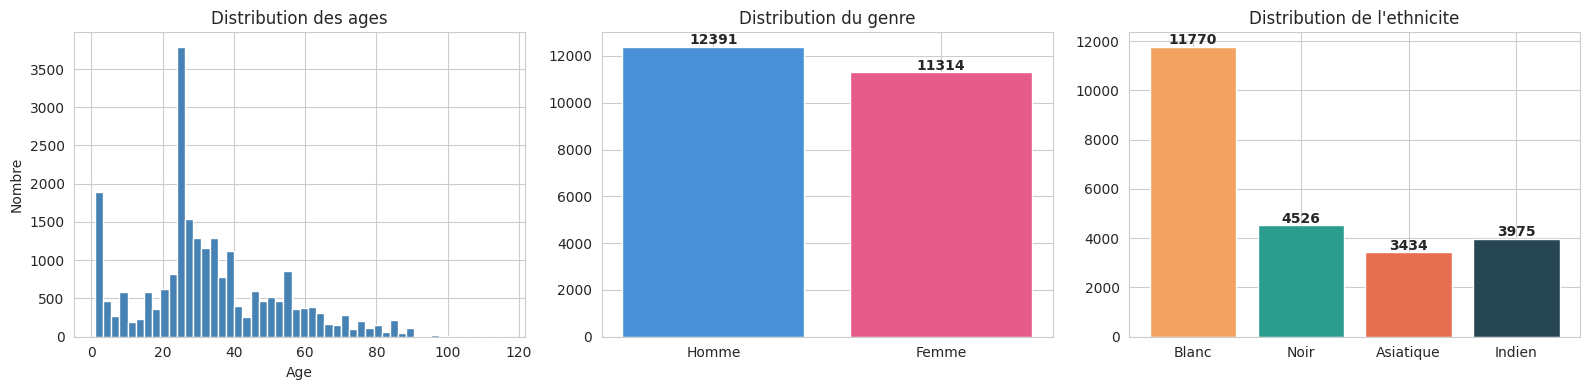

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution des ages
axes[0].hist(ages, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution des ages")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Nombre")

# Distribution du genre
gender_labels = ["Homme", "Femme"]
gender_counts = [int((genders == 0).sum()), int((genders == 1).sum())]
axes[1].bar(gender_labels, gender_counts, color=["#4A90D9", "#E55B8A"])
axes[1].set_title("Distribution du genre")
for i, v in enumerate(gender_counts):
    axes[1].text(i, v + 100, str(v), ha="center", fontweight="bold")

# Distribution de l'ethnicite
eth_labels = ["Blanc", "Noir", "Asiatique", "Indien"]
eth_counts = np.bincount(ethnicities, minlength=4)
axes[2].bar(eth_labels, eth_counts, color=["#F4A261", "#2A9D8F", "#E76F51", "#264653"])
axes[2].set_title("Distribution de l'ethnicite")
for i, v in enumerate(eth_counts):
    axes[2].text(i, v + 100, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dataset_distribution.png", dpi=150)
plt.show()

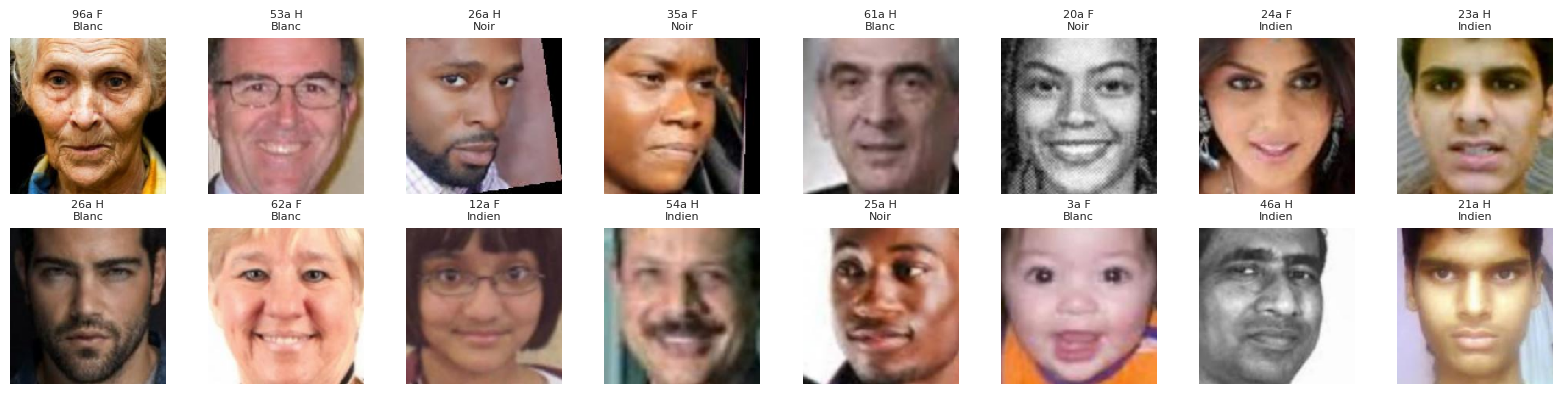

In [7]:
# Echantillon d'images
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
indices = np.random.choice(len(images), 16, replace=False)
gender_map = {0: "H", 1: "F"}
eth_map = {0: "Blanc", 1: "Noir", 2: "Asiat.", 3: "Indien"}

for i, idx in enumerate(indices):
    ax = axes[i // 8][i % 8]
    ax.imshow(images[idx].astype(np.uint8))
    ax.set_title(
        f"{int(ages[idx])}a {gender_map[int(genders[idx])]}\n{eth_map[int(ethnicities[idx])]}",
        fontsize=8,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## 6. Split Train / Validation / Test


In [8]:
idx = np.arange(len(images))
idx_train, idx_test = train_test_split(idx, test_size=0.15, random_state=42)
idx_train, idx_val = train_test_split(idx_train, test_size=0.15, random_state=42)

X_train, X_val, X_test = images[idx_train], images[idx_val], images[idx_test]
y_age_train, y_age_val, y_age_test = ages[idx_train], ages[idx_val], ages[idx_test]
y_gen_train, y_gen_val, y_gen_test = (
    genders[idx_train],
    genders[idx_val],
    genders[idx_test],
)
y_eth_train, y_eth_val, y_eth_test = (
    ethnicities[idx_train],
    ethnicities[idx_val],
    ethnicities[idx_test],
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

# Liberer la memoire du dataset complet
del images, ages, genders, ethnicities
import gc

gc.collect()

Train: 17126 | Val: 3023 | Test: 3556


11042

## 7. Architecture MoE


In [9]:
class MoEHead(layers.Layer):
    """
    Mixture of Experts head pour une tache.
    Chaque expert est un petit MLP. Le gating network decide
    le poids de chaque expert pour chaque input.
    """

    def __init__(
        self, num_experts, expert_hidden, output_dim, name_prefix="moe", **kwargs
    ):
        super().__init__(**kwargs)
        self.num_experts = num_experts
        self.expert_hidden = expert_hidden
        self.output_dim = output_dim
        self.name_prefix = name_prefix

        # Gating network
        self.gate_dense = layers.Dense(
            64, activation="relu", name=f"{name_prefix}_gate_dense"
        )
        self.gate_out = layers.Dense(
            num_experts, activation="softmax", name=f"{name_prefix}_gate_out"
        )

        # Experts
        self.expert_hiddens = []
        self.expert_dropouts = []
        self.expert_outputs = []
        for i in range(num_experts):
            self.expert_hiddens.append(
                layers.Dense(
                    expert_hidden, activation="relu", name=f"{name_prefix}_exp{i}_h"
                )
            )
            self.expert_dropouts.append(
                layers.Dropout(0.2, name=f"{name_prefix}_exp{i}_drop")
            )
            self.expert_outputs.append(
                layers.Dense(output_dim, name=f"{name_prefix}_exp{i}_out")
            )

    def call(self, features, training=False):
        # Gating: (batch, num_experts)
        gate = self.gate_dense(features)
        gate = self.gate_out(gate)

        # Experts
        expert_outs = []
        for i in range(self.num_experts):
            x = self.expert_hiddens[i](features)
            x = self.expert_dropouts[i](x, training=training)
            x = self.expert_outputs[i](x)
            expert_outs.append(x)

        # Stack: (batch, num_experts, output_dim)
        expert_stack = tf.stack(expert_outs, axis=1)

        # Gate: (batch, num_experts, 1)
        gate_expanded = tf.expand_dims(gate, axis=-1)

        # Weighted sum: (batch, output_dim)
        return tf.reduce_sum(expert_stack * gate_expanded, axis=1)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "num_experts": self.num_experts,
                "expert_hidden": self.expert_hidden,
                "output_dim": self.output_dim,
                "name_prefix": self.name_prefix,
            }
        )
        return config

In [10]:
def build_moe_model(input_shape=(128, 128, 3), num_experts=3, expert_hidden=128):
    """Construit le modele MoE avec backbone MobileNetV3Small + Rescaling."""

    backbone = MobileNetV3Small(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
        include_preprocessing=False,
    )

    # Freeze TOUT le backbone pour le warmup
    for layer in backbone.layers:
        layer.trainable = False

    # Input -> Rescaling [-1, 1] (requis par MobileNetV3 imagenet)
    inputs = layers.Input(shape=input_shape, name="input_image")
    x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="rescaling")(inputs)
    x = backbone(x, training=False)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn_features")(x)
    features = layers.Dropout(0.3, name="drop_features")(x)

    # --- Gender MoE (binary) ---
    gender_moe = MoEHead(num_experts, expert_hidden, 1, name_prefix="gender")
    gender_raw = gender_moe(features)
    gender_output = layers.Activation("sigmoid", name="gender_output")(gender_raw)

    # --- Age MoE (regression) ---
    age_moe = MoEHead(num_experts, expert_hidden, 1, name_prefix="age")
    age_output = layers.Activation("linear", name="age_output")(age_moe(features))

    # --- Ethnicity MoE (4 classes) ---
    eth_moe = MoEHead(num_experts, expert_hidden, 4, name_prefix="ethnicity")
    eth_raw = eth_moe(features)
    eth_output = layers.Activation("softmax", name="ethnicity_output")(eth_raw)

    model = Model(inputs=inputs, outputs=[gender_output, age_output, eth_output])
    return model, backbone


model, backbone = build_moe_model(
    input_shape=(INPUT_SIZE, INPUT_SIZE, 3),
    num_experts=NUM_EXPERTS,
    expert_hidden=EXPERT_HIDDEN,
)

# Verifier le freeze
trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
total = model.count_params()
print(f"Total params: {total:,}")
print(f"Trainable (MoE heads only): {trainable:,}")
print(f"Frozen (backbone): {total - trainable:,}")
model.summary(show_trainable=True)

/home/optimalako/Projet/SAE/.venv/lib/python3.12/site-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(
I0000 00:00:1771334860.351644   74606 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4081 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Total params: 1,719,819
Trainable (MoE heads only): 779,547
Frozen (backbone): 940,272


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)      ┃ Output Shape    ┃   Param # ┃ Connected to   ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ input_image       │ (None, 128,     │         0 │ -              │   -   │
│ (InputLayer)      │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ rescaling         │ (None, 128,     │         0 │ input_image[0… │   -   │
│ (Rescaling)       │ 128, 3)         │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ MobileNetV3Small  │ (None, 4, 4,    │   939,120 │ rescaling[0][… │   Y   │
│ (Functional)      │ 576)            │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ gap               │ (None, 576)     │         0 │ MobileNetV3Sm… │   -   │
│ (GlobalAveragePo… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ bn_features       │ (None, 576)     │     2,304 │ gap[0][0]      │   Y   │
│ (BatchNormalizat… │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ drop_features     │ (None, 576)     │         0 │ bn_features[0… │   -   │
│ (Dropout)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mo_e_head         │ (None, 1)       │   259,078 │ drop_features… │   Y   │
│ (MoEHead)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mo_e_head_1       │ (None, 1)       │   259,078 │ drop_features… │   Y   │
│ (MoEHead)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ mo_e_head_2       │ (None, 4)       │   260,239 │ drop_features… │   Y   │
│ (MoEHead)         │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ gender_output     │ (None, 1)       │         0 │ mo_e_head[0][… │   -   │
│ (Activation)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ age_output        │ (None, 1)       │         0 │ mo_e_head_1[0… │   -   │
│ (Activation)      │                 │           │                │       │
├───────────────────┼─────────────────┼───────────┼────────────────┼───────┤
│ ethnicity_output  │ (None, 4)       │         0 │ mo_e_head_2[0… │   -   │
│ (Activation)      │                 │           │                │       │
└───────────────────┴─────────────────┴───────────┴────────────────┴───────┘

 Total params: 1,719,819 (6.56 MB)

 Trainable params: 779,547 (2.97 MB)

 Non-trainable params: 940,272 (3.59 MB)

In [11]:
# Visualisation de l'architecture
keras.utils.plot_model(
    model,
    to_file=f"{OUTPUT_DIR}/moe_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=100,
)

total_params = model.count_params()
trainable_params = sum(
    tf.keras.backend.count_params(w) for w in model.trainable_weights
)
print(f"\nTotal params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable: {total_params - trainable_params:,}")

You must install pydot (`pip install pydot`) for `plot_model` to work.

Total params: 1,719,819
Trainable params: 779,547
Non-trainable: 940,272


## 8. Data augmentation & datasets


Datasets crees avec succes !


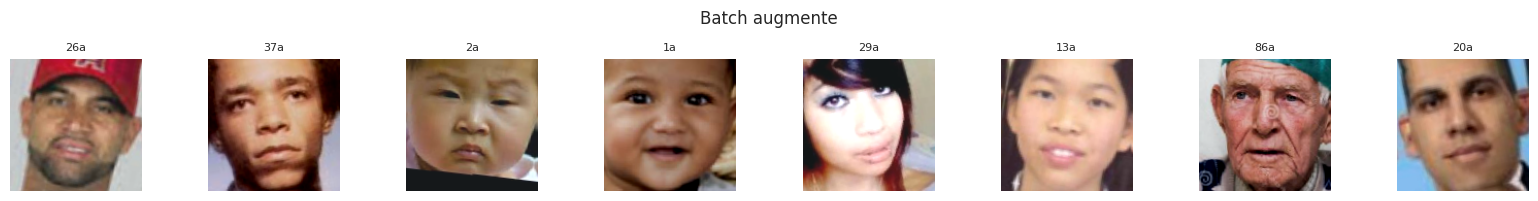

2026-02-17 14:27:45.886478: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ],
    name="augmentation",
)


def make_dataset(X, y_gen, y_age, y_eth, batch_size, augment=False):
    with tf.device("/cpu:0"):
        ds = tf.data.Dataset.from_tensor_slices(
            (
                X,
                {
                    "gender_output": y_gen,
                    "age_output": y_age,
                    "ethnicity_output": y_eth,
                },
            )
        )
    if augment:
        ds = ds.shuffle(len(X))
    ds = ds.batch(batch_size)
    # Cast uint8 -> float32 (fait batch par batch, econome en memoire)
    ds = ds.map(
        lambda x, y: (tf.cast(x, tf.float32), y),
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    if augment:
        ds = ds.map(
            lambda x, y: (augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(
    X_train, y_gen_train, y_age_train, y_eth_train, BATCH_SIZE, augment=True
)
val_ds = make_dataset(X_val, y_gen_val, y_age_val, y_eth_val, BATCH_SIZE)
test_ds = make_dataset(X_test, y_gen_test, y_age_test, y_eth_test, BATCH_SIZE)

# Liberer les arrays numpy (les donnees sont maintenant dans tf.data)
del X_train, X_val
gc.collect()

print("Datasets crees avec succes !")

# Apercu d'un batch augmente
for batch_x, batch_y in train_ds.take(1):
    fig, axes = plt.subplots(1, 8, figsize=(16, 2))
    for i in range(8):
        axes[i].imshow(batch_x[i].numpy().clip(0, 255).astype(np.uint8))
        axes[i].set_title(f"{int(batch_y['age_output'][i])}a", fontsize=8)
        axes[i].axis("off")
    plt.suptitle("Batch augmente")
    plt.tight_layout()
    plt.show()

## 9. Phase 1 : Warmup (backbone freeze)


In [13]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss={
        "gender_output": "binary_crossentropy",
        "age_output": "mae",
        "ethnicity_output": "sparse_categorical_crossentropy",
    },
    loss_weights={
        "gender_output": 1.0,
        "age_output": 0.1,
        "ethnicity_output": 1.0,
    },
    metrics={
        "gender_output": ["accuracy"],
        "age_output": ["mae"],
        "ethnicity_output": ["accuracy"],
    },
)

callbacks_phase1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        min_delta=0.01,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        f"{OUTPUT_DIR}/moe_warmup_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

print(f"Phase 1: Warmup ({WARMUP_EPOCHS} epochs, backbone FREEZE)")

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=callbacks_phase1,
    verbose=1,
)

Phase 1: Warmup (25 epochs, backbone FREEZE)
Epoch 1/25


2026-02-17 14:27:56.137467: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f9f34002560 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-17 14:27:56.137562: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2026-02-17 14:27:56.446371: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-17 14:27:58.847710: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91800
2026-02-17 14:27:59.916117: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-17 14:28:00.

536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - age_output_loss: 18.4006 - age_output_mae: 18.4007 - ethnicity_output_accuracy: 0.5295 - ethnicity_output_loss: 1.2009 - gender_output_accuracy: 0.7378 - gender_output_loss: 0.5561 - loss: 3.5970
Epoch 1: val_loss improved from None to 2.20404, saving model to output_moe/moe_warmup_best.keras

Epoch 1: finished saving model to output_moe/moe_warmup_best.keras
536/536 ━━━━━━━━━━━━━━━━━━━━ 80s 89ms/step - age_output_loss: 14.1758 - age_output_mae: 14.1806 - ethnicity_output_accuracy: 0.5720 - ethnicity_output_loss: 1.0908 - gender_output_accuracy: 0.7633 - gender_output_loss: 0.5099 - loss: 3.0179 - val_age_output_loss: 10.1735 - val_age_output_mae: 10.1750 - val_ethnicity_output_accuracy: 0.6732 - val_ethnicity_output_loss: 0.8224 - val_gender_output_accuracy: 0.8290 - val_gender_output_loss: 0.3648 - val_loss: 2.2040 - learning_rate: 0.0010
Epoch 2/25
535/536 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - age_output_loss: 10.8761 - age_output_mae: 10.87

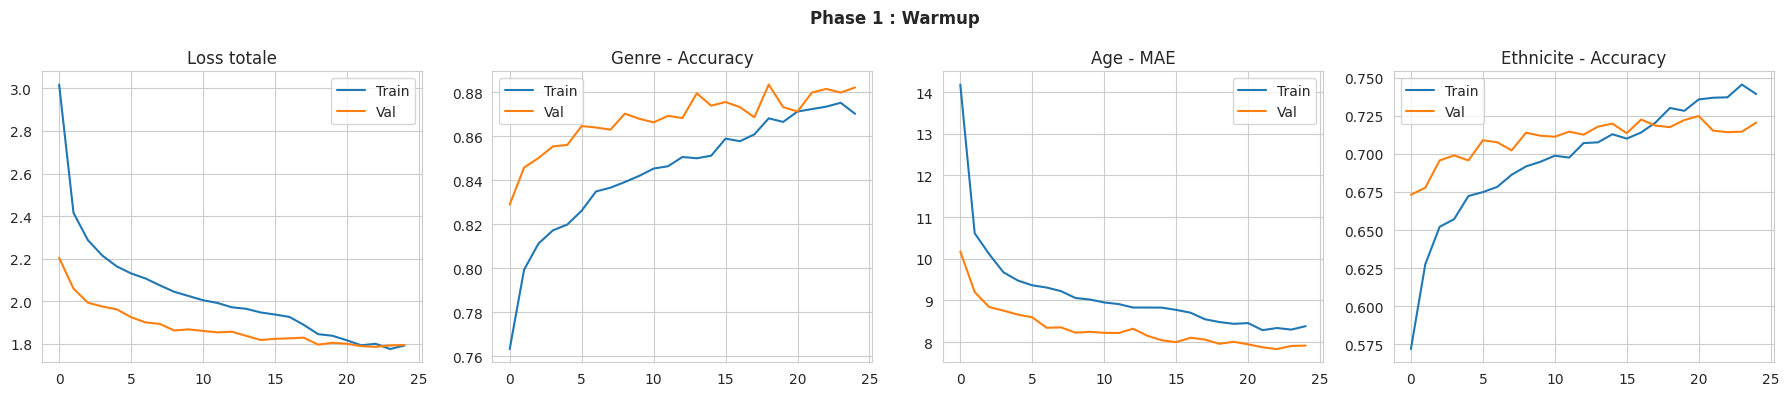

In [14]:
# Courbes Phase 1
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(history1.history["loss"], label="Train")
axes[0].plot(history1.history["val_loss"], label="Val")
axes[0].set_title("Loss totale")
axes[0].legend()

axes[1].plot(history1.history["gender_output_accuracy"], label="Train")
axes[1].plot(history1.history["val_gender_output_accuracy"], label="Val")
axes[1].set_title("Genre - Accuracy")
axes[1].legend()

axes[2].plot(history1.history["age_output_mae"], label="Train")
axes[2].plot(history1.history["val_age_output_mae"], label="Val")
axes[2].set_title("Age - MAE")
axes[2].legend()

axes[3].plot(history1.history["ethnicity_output_accuracy"], label="Train")
axes[3].plot(history1.history["val_ethnicity_output_accuracy"], label="Val")
axes[3].set_title("Ethnicite - Accuracy")
axes[3].legend()

plt.suptitle("Phase 1 : Warmup", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/phase1_curves.png", dpi=150)
plt.show()

## 10. Phase 2 : Degel progressif (unfreezing par blocs)

Le fine-tuning se fait en **3 etapes** pour eviter le collapse :

1. Degel des 30 dernieres couches du backbone
2. Degel des 60 dernieres couches
3. Degel complet

Chaque etape utilise un LR tres faible (2e-5) avec monitoring strict du val_loss.


In [15]:
def progressive_unfreeze(backbone, model, num_layers_to_unfreeze):
    """Degel progressif : unfreeze les N dernieres couches du backbone."""
    total = len(backbone.layers)
    for layer in backbone.layers:
        layer.trainable = False
    for layer in backbone.layers[max(0, total - num_layers_to_unfreeze) :]:
        layer.trainable = True
    # GELER toutes les BatchNormalization pour eviter le catastrophic forgetting
    for layer in backbone.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False
    # Les MoE heads restent toujours trainable
    trainable_count = sum(
        tf.keras.backend.count_params(w) for w in model.trainable_weights
    )
    return trainable_count


def finetune_phase(
    model,
    backbone,
    unfreeze_layers,
    phase_name,
    lr,
    epochs_start,
    epochs_end,
    patience=5,
):
    """Execute une phase de fine-tuning avec degel progressif."""
    trainable_count = progressive_unfreeze(backbone, model, unfreeze_layers)
    print(f"\n{'='*60}")
    print(f"{phase_name}: Unfreeze {unfreeze_layers} dernieres couches")
    print(f"  Trainable params: {trainable_count:,}")
    print(f"  LR: {lr}, Epochs: {epochs_start}->{epochs_end}")
    print(f"{'='*60}")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss={
            "gender_output": "binary_crossentropy",
            "age_output": "mae",
            "ethnicity_output": "sparse_categorical_crossentropy",
        },
        loss_weights={
            "gender_output": 1.0,
            "age_output": 0.1,
            "ethnicity_output": 1.0,
        },
        metrics={
            "gender_output": ["accuracy"],
            "age_output": ["mae"],
            "ethnicity_output": ["accuracy"],
        },
    )

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            min_delta=0.005,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1
        ),
        ModelCheckpoint(
            f"{OUTPUT_DIR}/moe_best.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs_end,
        initial_epoch=epochs_start,
        callbacks=callbacks,
        verbose=1,
    )
    return history


# Phase 2a: Degel des 30 dernieres couches
warmup_end = len(history1.epoch)
phase2a_end = warmup_end + 15

history2a = finetune_phase(
    model,
    backbone,
    unfreeze_layers=30,
    phase_name="Phase 2a",
    lr=FINETUNE_LR,
    epochs_start=warmup_end,
    epochs_end=phase2a_end,
    patience=5,
)

# Phase 2b: Degel des 60 dernieres couches
phase2b_start = warmup_end + len(history2a.epoch)
phase2b_end = phase2b_start + 15

history2b = finetune_phase(
    model,
    backbone,
    unfreeze_layers=60,
    phase_name="Phase 2b",
    lr=FINETUNE_LR * 0.5,  # 1e-5
    epochs_start=phase2b_start,
    epochs_end=phase2b_end,
    patience=5,
)

# Phase 2c: Degel complet
phase2c_start = phase2b_start + len(history2b.epoch)
phase2c_end = phase2c_start + 20

history2c = finetune_phase(
    model,
    backbone,
    unfreeze_layers=len(backbone.layers),  # tout
    phase_name="Phase 2c (FULL)",
    lr=FINETUNE_LR * 0.25,  # 5e-6
    epochs_start=phase2c_start,
    epochs_end=phase2c_end,
    patience=7,
)

# Combiner les historiques pour le plot
history2 = type("History", (), {"history": {}})()
for key in history2a.history:
    history2.history[key] = (
        history2a.history[key]
        + history2b.history.get(key, [])
        + history2c.history.get(key, [])
    )

print(f"\nFine-tuning termine !")
print(f"  Total epochs: {phase2c_start + len(history2c.epoch)}")
final_trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f"  Trainable params final: {final_trainable:,}")


Phase 2a: Unfreeze 30 dernieres couches
  Trainable params: 1,362,747
  LR: 2e-05, Epochs: 25->40
Epoch 26/40
536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - age_output_loss: 8.1329 - age_output_mae: 8.1329 - ethnicity_output_accuracy: 0.7581 - ethnicity_output_loss: 0.6275 - gender_output_accuracy: 0.8830 - gender_output_loss: 0.2798 - loss: 1.7206
Epoch 26: val_loss improved from None to 1.69061, saving model to output_moe/moe_best.keras

Epoch 26: finished saving model to output_moe/moe_best.keras
536/536 ━━━━━━━━━━━━━━━━━━━━ 69s 77ms/step - age_output_loss: 8.0827 - age_output_mae: 8.0869 - ethnicity_output_accuracy: 0.7633 - ethnicity_output_loss: 0.6119 - gender_output_accuracy: 0.8850 - gender_output_loss: 0.2735 - loss: 1.6944 - val_age_output_loss: 7.4795 - val_age_output_mae: 7.4725 - val_ethnicity_output_accuracy: 0.7403 - val_ethnicity_output_loss: 0.6681 - val_gender_output_accuracy: 0.8879 - val_gender_output_loss: 0.2741 - val_loss: 1.6906 - learning_rate: 2.0000e-05
Epoch 

2026-02-17 14:35:07.610854: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 6291840 bytes after encountering the first element of size 6291840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - age_output_loss: 7.9690 - age_output_mae: 7.9690 - ethnicity_output_accuracy: 0.7746 - ethnicity_output_loss: 0.5797 - gender_output_accuracy: 0.8854 - gender_output_loss: 0.2688 - loss: 1.6454
Epoch 28: val_loss improved from 1.66680 to 1.64805, saving model to output_moe/moe_best.keras

Epoch 28: finished saving model to output_moe/moe_best.keras
536/536 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - age_output_loss: 7.7722 - age_output_mae: 7.7668 - ethnicity_output_accuracy: 0.7731 - ethnicity_output_loss: 0.5808 - gender_output_accuracy: 0.8891 - gender_output_loss: 0.2644 - loss: 1.6214 - val_age_output_loss: 7.3267 - val_age_output_mae: 7.3179 - val_ethnicity_output_accuracy: 0.7529 - val_ethnicity_output_loss: 0.6477 - val_gender_output_accuracy: 0.8898 - val_gender_output_loss: 0.2675 - val_loss: 1.6481 - learning_rate: 2.0000e-05
Epoch 29/40
533/536 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - age_output_loss: 7.7176 - age_output_mae: 7.7176 - ethnici

2026-02-17 14:36:42.006675: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 6291840 bytes after encountering the first element of size 6291840 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


536/536 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - age_output_loss: 7.3044 - age_output_mae: 7.3043 - ethnicity_output_accuracy: 0.7966 - ethnicity_output_loss: 0.5310 - gender_output_accuracy: 0.8970 - gender_output_loss: 0.2477 - loss: 1.5092
Epoch 36: val_loss improved from 1.56674 to 1.56116, saving model to output_moe/moe_best.keras

Epoch 36: finished saving model to output_moe/moe_best.keras
536/536 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - age_output_loss: 7.3582 - age_output_mae: 7.3507 - ethnicity_output_accuracy: 0.7983 - ethnicity_output_loss: 0.5282 - gender_output_accuracy: 0.8989 - gender_output_loss: 0.2445 - loss: 1.5086 - val_age_output_loss: 6.9478 - val_age_output_mae: 6.9391 - val_ethnicity_output_accuracy: 0.7708 - val_ethnicity_output_loss: 0.6121 - val_gender_output_accuracy: 0.8945 - val_gender_output_loss: 0.2540 - val_loss: 1.5612 - learning_rate: 2.0000e-05
Epoch 37/40
535/536 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - age_output_loss: 7.2312 - age_output_mae: 7.2312 - ethnici

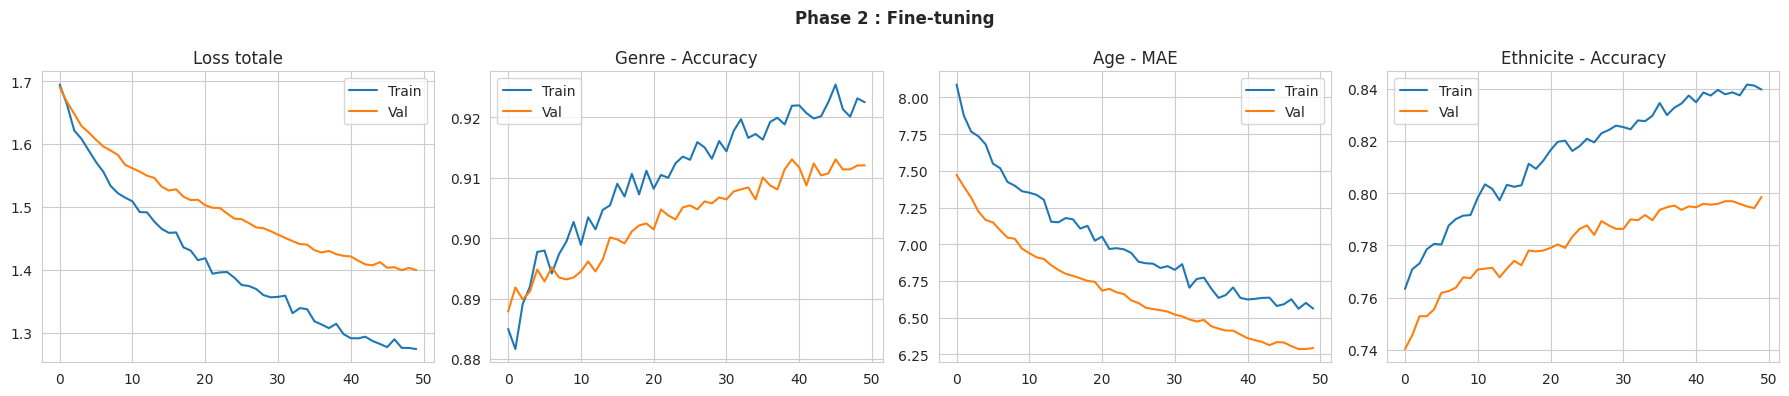

In [16]:
# Courbes Phase 2
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(history2.history["loss"], label="Train")
axes[0].plot(history2.history["val_loss"], label="Val")
axes[0].set_title("Loss totale")
axes[0].legend()

axes[1].plot(history2.history["gender_output_accuracy"], label="Train")
axes[1].plot(history2.history["val_gender_output_accuracy"], label="Val")
axes[1].set_title("Genre - Accuracy")
axes[1].legend()

axes[2].plot(history2.history["age_output_mae"], label="Train")
axes[2].plot(history2.history["val_age_output_mae"], label="Val")
axes[2].set_title("Age - MAE")
axes[2].legend()

axes[3].plot(history2.history["ethnicity_output_accuracy"], label="Train")
axes[3].plot(history2.history["val_ethnicity_output_accuracy"], label="Val")
axes[3].set_title("Ethnicite - Accuracy")
axes[3].legend()

plt.suptitle("Phase 2 : Fine-tuning", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/phase2_curves.png", dpi=150)
plt.show()

## 11. Evaluation sur le test set


In [17]:
# Charger le meilleur checkpoint (warmup ou fine-tuning)
import os

warmup_path = f"{OUTPUT_DIR}/moe_warmup_best.keras"
best_path = f"{OUTPUT_DIR}/moe_best.keras"

# Comparer les val_loss pour choisir le meilleur
warmup_val = model.evaluate(val_ds, verbose=0)[0]  # loss actuelle

# Recharger le warmup pour comparer
model_warmup = keras.models.load_model(warmup_path, custom_objects={"MoEHead": MoEHead})
warmup_val_loss = model_warmup.evaluate(val_ds, verbose=0)[0]

current_val_loss = model.evaluate(val_ds, verbose=0)[0]

if warmup_val_loss < current_val_loss:
    print(
        f"Le warmup est meilleur (val_loss: {warmup_val_loss:.4f} < {current_val_loss:.4f})"
    )
    model = model_warmup
else:
    print(
        f"Le fine-tuning est meilleur (val_loss: {current_val_loss:.4f} < {warmup_val_loss:.4f})"
    )

del model_warmup

print("=" * 50)
print("EVALUATION SUR LE TEST SET")
print("=" * 50)

results = model.evaluate(test_ds, verbose=1)

print(f"\nResultats:")
for name, value in zip(model.metrics_names, results):
    print(f"  {name}: {value:.4f}")

/home/optimalako/Projet/SAE/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'mo_e_head', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/optimalako/Projet/SAE/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'mo_e_head_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/home/optimalako/Projet/SAE/.venv/lib/python3.12/site-packages/keras/src/layers/layer.py:424: UserWarning: `buil

Le fine-tuning est meilleur (val_loss: 1.4031 < 1.7859)
EVALUATION SUR LE TEST SET
112/112 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - age_output_loss: 6.5085 - age_output_mae: 6.5035 - ethnicity_output_accuracy: 0.7972 - ethnicity_output_loss: 0.5583 - gender_output_accuracy: 0.8906 - gender_output_loss: 0.2622 - loss: 1.4755

Resultats:
  loss: 1.4755
  compile_metrics: 0.2622
  gender_output_loss: 6.5085
  age_output_loss: 0.5583
  ethnicity_output_loss: 6.5035


In [18]:
# Predictions detaillees
from sklearn.metrics import classification_report, confusion_matrix

pred_gender, pred_age, pred_eth = model.predict(test_ds, verbose=1)

# Genre
pred_gender_class = (pred_gender.flatten() > 0.5).astype(int)
print("\n=== GENRE ===")
print(
    classification_report(
        y_gen_test, pred_gender_class, target_names=["Homme", "Femme"]
    )
)

# Age
pred_age_int = pred_age.flatten().astype(int).clip(0, 116)
age_mae = np.abs(pred_age_int - y_age_test).mean()
print(f"\n=== AGE ===")
print(f"MAE: {age_mae:.2f} ans")

# Ethnicite
pred_eth_class = pred_eth.argmax(axis=1)
eth_names = ["Blanc", "Noir", "Asiatique", "Indien"]
print("\n=== ETHNICITE ===")
print(classification_report(y_eth_test, pred_eth_class, target_names=eth_names))

112/112 ━━━━━━━━━━━━━━━━━━━━ 14s 67ms/step

=== GENRE ===
              precision    recall  f1-score   support

       Homme       0.88      0.91      0.90      1829
       Femme       0.90      0.87      0.89      1727

    accuracy                           0.89      3556
   macro avg       0.89      0.89      0.89      3556
weighted avg       0.89      0.89      0.89      3556


=== AGE ===
MAE: 6.57 ans

=== ETHNICITE ===
              precision    recall  f1-score   support

       Blanc       0.81      0.88      0.85      1747
        Noir       0.83      0.79      0.81       659
   Asiatique       0.78      0.68      0.73       525
      Indien       0.73      0.65      0.69       625

    accuracy                           0.80      3556
   macro avg       0.79      0.75      0.77      3556
weighted avg       0.80      0.80      0.79      3556



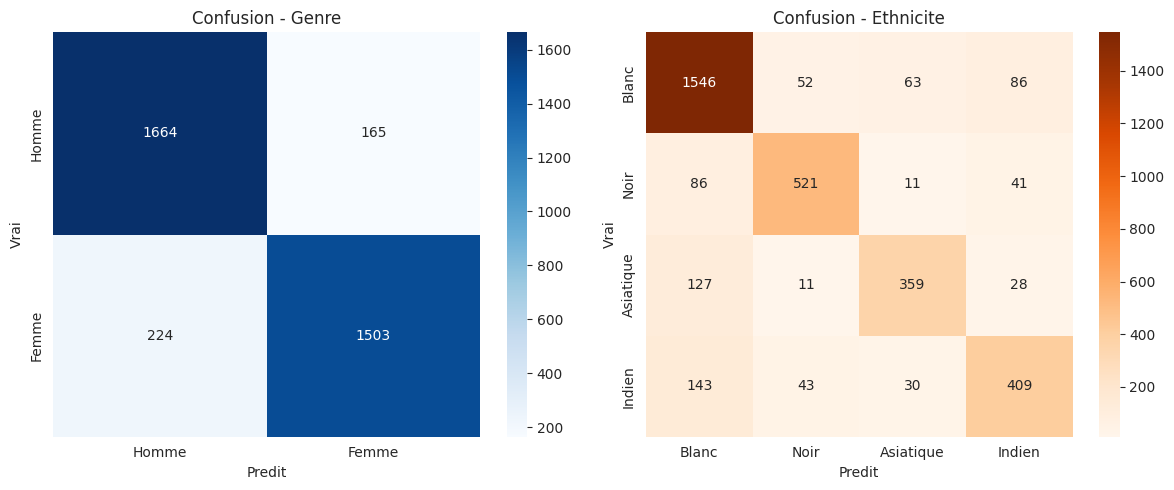

In [19]:
# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Genre
cm_gender = confusion_matrix(y_gen_test, pred_gender_class)
sns.heatmap(
    cm_gender,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Homme", "Femme"],
    yticklabels=["Homme", "Femme"],
    ax=axes[0],
)
axes[0].set_title("Confusion - Genre")
axes[0].set_ylabel("Vrai")
axes[0].set_xlabel("Predit")

# Ethnicite
cm_eth = confusion_matrix(y_eth_test, pred_eth_class)
sns.heatmap(
    cm_eth,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=eth_names,
    yticklabels=eth_names,
    ax=axes[1],
)
axes[1].set_title("Confusion - Ethnicite")
axes[1].set_ylabel("Vrai")
axes[1].set_xlabel("Predit")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrices.png", dpi=150)
plt.show()

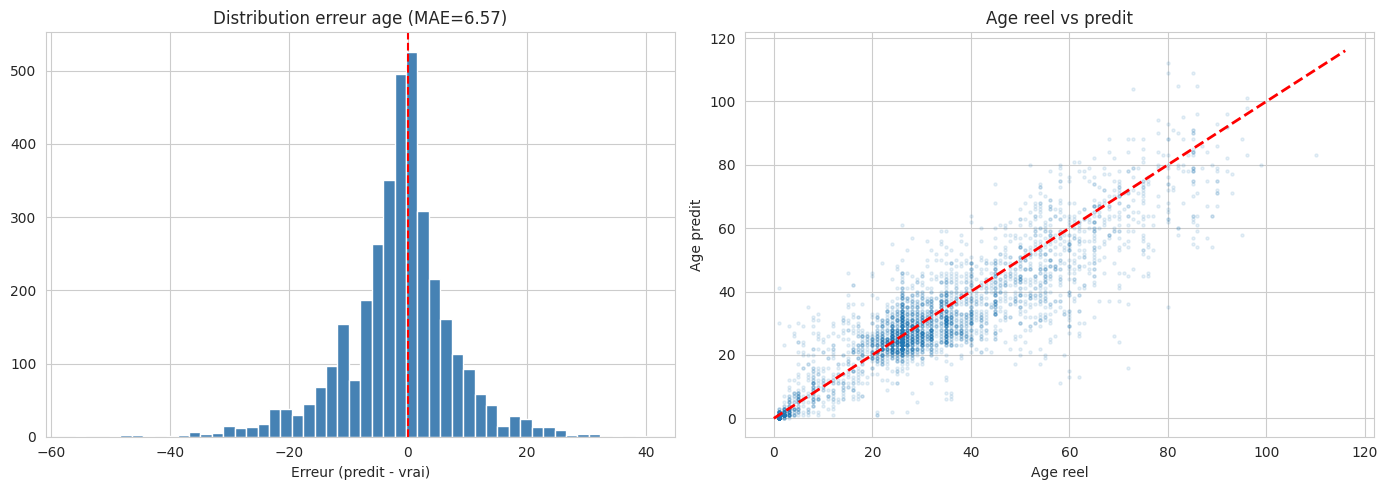

In [20]:
# Distribution erreur age
age_errors = pred_age_int - y_age_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(age_errors, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(x=0, color="red", linestyle="--")
axes[0].set_title(f"Distribution erreur age (MAE={age_mae:.2f})")
axes[0].set_xlabel("Erreur (predit - vrai)")

axes[1].scatter(y_age_test, pred_age_int, alpha=0.1, s=5)
axes[1].plot([0, 116], [0, 116], "r--", linewidth=2)
axes[1].set_xlabel("Age reel")
axes[1].set_ylabel("Age predit")
axes[1].set_title("Age reel vs predit")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/age_analysis.png", dpi=150)
plt.show()

## 12. Analyse des Gating Networks

Visualisons quels experts sont actives pour differents types d'inputs.


In [21]:
# Extraire les sorties des gating networks
gate_layer_names = [
    "gender_gate_out",
    "age_gate_out",
    "ethnicity_gate_out",
]

# Trouver les couches
gate_outputs = []
for name in gate_layer_names:
    found = False
    for layer in model.layers:
        if hasattr(layer, "gate_out"):
            found = True
            break
    if not found:
        # Chercher dans les sous-couches
        for layer in model.layers:
            if name in layer.name:
                gate_outputs.append(layer.output)
                break

# Methode alternative: predire sur un batch et analyser les stats
sample_batch = X_test[:200]
sample_ages = y_age_test[:200]
sample_genders = y_gen_test[:200]
sample_ethnicities = y_eth_test[:200]

print("Gating analysis sur 200 echantillons du test set")
print(f"  Ages: {sample_ages.min():.0f}-{sample_ages.max():.0f}")
print(
    f"  Genres: {int((sample_genders == 0).sum())}H / {int((sample_genders == 1).sum())}F"
)
print(f"  Ethnicites: {np.bincount(sample_ethnicities.astype(int), minlength=4)}")

Gating analysis sur 200 echantillons du test set
  Ages: 1-95
  Genres: 106H / 94F
  Ethnicites: [103  29  31  37]


## 13. Sauvegarde du modele Keras


In [22]:
keras_path = f"{OUTPUT_DIR}/moe_mobilenetv3.keras"
model.save(keras_path)
print(f"Modele Keras sauvegarde: {keras_path}")

# Taille du fichier
size_mb = os.path.getsize(keras_path) / (1024 * 1024)
print(f"Taille: {size_mb:.1f} MB")

Modele Keras sauvegarde: output_moe/moe_mobilenetv3.keras
Taille: 20.2 MB


## 14. Conversion TFLite


In [23]:
# Conversion
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float32]

tflite_model = converter.convert()

tflite_path = f"{OUTPUT_DIR}/moe_mobilenetv3.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

size_mb = len(tflite_model) / (1024 * 1024)
print(f"Modele TFLite sauvegarde: {tflite_path}")
print(f"Taille: {size_mb:.1f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpzxyzuy26/assets


INFO:tensorflow:Assets written to: /tmp/tmpzxyzuy26/assets


Saved artifact at '/tmp/tmpzxyzuy26'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  List[TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)]
Captures:
  140327247467280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140327247468432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140327247468048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140327247469008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140327247476112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140327247463248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140327247466704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140327247469200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140327247468240: TensorSpec(shape

W0000 00:00:1771336200.556402   74606 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1771336200.556436   74606 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-02-17 14:50:00.556943: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpzxyzuy26
2026-02-17 14:50:00.571259: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-02-17 14:50:00.571277: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpzxyzuy26
I0000 00:00:1771336200.821653   74606 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-02-17 14:50:00.849408: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-02-17 14:50:01.833018: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpzxyzuy26
2026-02-17 14:50:02.101010: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

Modele TFLite sauvegarde: output_moe/moe_mobilenetv3.tflite
Taille: 6.5 MB


In [24]:
# Verification du modele TFLite
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

print("Inputs TFLite:")
for inp in interpreter.get_input_details():
    print(
        f"  [{inp['index']}] {inp['name']}: shape={inp['shape']}, dtype={inp['dtype']}"
    )

print("\nOutputs TFLite:")
for out in interpreter.get_output_details():
    print(
        f"  [{out['index']}] {out['name']}: shape={out['shape']}, dtype={out['dtype']}"
    )

Inputs TFLite:
  [0] serving_default_input_image:0: shape=[  1 128 128   3], dtype=<class 'numpy.float32'>

Outputs TFLite:
  [277] StatefulPartitionedCall_1:1: shape=[1 1], dtype=<class 'numpy.float32'>
  [305] StatefulPartitionedCall_1:0: shape=[1 1], dtype=<class 'numpy.float32'>
  [291] StatefulPartitionedCall_1:2: shape=[1 4], dtype=<class 'numpy.float32'>


/home/optimalako/Projet/SAE/.venv/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Test inference TFLite:
  Gender: 0.979 (Femme)
  Age: 8.1 (vrai: 4)
  Ethnicity: Noir (vrai: Indien)


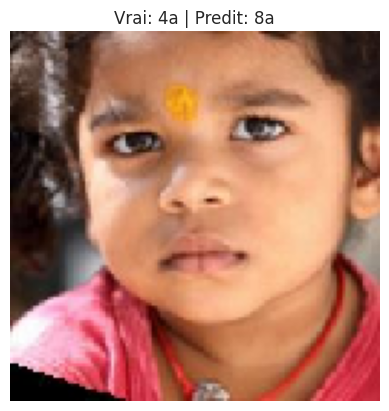

In [25]:
# Test rapide d'inference TFLite
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Prendre une image de test (cast uint8 -> float32 pour TFLite)
test_img = X_test[0:1].astype(np.float32)
interpreter.set_tensor(input_details[0]["index"], test_img)
interpreter.invoke()

# ATTENTION: TFLite réordonne les sorties !
# output[0] = age (suffix :1), output[1] = gender (suffix :0), output[2] = ethnicity (suffix :2)
age_out = interpreter.get_tensor(output_details[0]["index"])
gender_out = interpreter.get_tensor(output_details[1]["index"])
eth_out = interpreter.get_tensor(output_details[2]["index"])

print(f"Test inference TFLite:")
print(
    f"  Gender: {gender_out[0][0]:.3f} ({'Femme' if gender_out[0][0] > 0.5 else 'Homme'})"
)
print(f"  Age: {age_out[0][0]:.1f} (vrai: {int(y_age_test[0])})")
print(
    f"  Ethnicity: {eth_names[eth_out[0].argmax()]} (vrai: {eth_names[int(y_eth_test[0])]})"
)

# Afficher l'image
plt.imshow(X_test[0].astype(np.uint8))
plt.title(f"Vrai: {int(y_age_test[0])}a | Predit: {age_out[0][0]:.0f}a")
plt.axis("off")
plt.show()

## 15. Copier le modele dans l'app Android

Execute cette cellule pour copier automatiquement le `.tflite` dans les assets de l'app.


In [26]:
import shutil

# Chemin relatif vers les assets de l'app
assets_dir = "../FacePredictor/app/src/main/assets"
dest_path = os.path.join(assets_dir, "moe_mobilenetv3.tflite")

if os.path.exists(assets_dir):
    shutil.copy2(tflite_path, dest_path)
    print(f"Modele copie vers: {dest_path}")
    print(f"Taille: {os.path.getsize(dest_path) / (1024*1024):.1f} MB")
    print("\nTu peux maintenant rebuild l'APK !")
else:
    print(f"Dossier assets non trouve: {assets_dir}")
    print(f"Copie manuellement: cp {tflite_path} <projet>/app/src/main/assets/")

Modele copie vers: ../FacePredictor/app/src/main/assets/moe_mobilenetv3.tflite
Taille: 6.5 MB

Tu peux maintenant rebuild l'APK !
